In [2]:
import numpy as np
import pandas as pd

# =========================
# 1) Configuración
# =========================
SEED = 42
np.random.seed(SEED)

N_ROWS = 12000              # tamaño dataset (ajustable)
START_DATE = "2025-01-01"   # rango de fechas
END_DATE   = "2025-12-31"

ON_TIME_THRESHOLD_MIN = 5   # umbral puntualidad (min)

routes = [
    ("DEN", "IBZ",  70, 450),
    ("DEN", "FOR",  55, 420),
    ("DEN", "PMI", 300, 900),
    ("VAL", "IBZ", 300, 1100),
    ("VAL", "PMI", 330, 1200),
    ("BCN", "PMI", 450, 1300),
    ("BCN", "IBZ", 410, 1250),
    ("ALG", "IBZ", 240, 950),
    ("ALG", "PMI", 260, 980),
    ("MAH", "BCN", 210, 800),
]

# Tipos de buque (simplificado)
vessel_types = [
    ("FAST",  900, 1.10),  # (tipo, capacidad pax, factor coste)
    ("ECO",  1200, 1.00),
    ("MEGA", 1800, 1.25),
]

# Causas / disrupciones
reasons = [
    ("WEATHER", 0.18),
    ("PORT_CONGESTION", 0.14),
    ("TECHNICAL", 0.10),
    ("CREW", 0.05),
    ("LATE_BOARDING", 0.12),
    ("SECURITY", 0.04),
    ("SUPPLY_ISSUE", 0.03),
    ("NONE", 0.34),
]
reason_names = [r[0] for r in reasons]
reason_probs = np.array([r[1] for r in reasons], dtype=float)
reason_probs /= reason_probs.sum()

# Clima (categoría)
weather_cats = ["CALM", "WINDY", "ROUGH", "STORM"]
weather_probs = [0.55, 0.25, 0.15, 0.05]

# =========================
# 2) Helpers
# =========================
def random_dates(n, start, end):
    start = pd.to_datetime(start)
    end   = pd.to_datetime(end)
    # fecha aleatoria con distribución uniforme
    return start + (end - start) * np.random.rand(n)

def choose_weighted(items, probs, size):
    idx = np.random.choice(len(items), size=size, p=probs)
    return np.array(items)[idx]

def route_baseline_delay(route_key):
    # rutas cortas: menos margen, pero más sensibilidad a puerto/embarque
    # rutas largas: más riesgo por clima y técnico
    if route_key in [("DEN","FOR"), ("DEN","IBZ")]:
        return 6
    if route_key in [("DEN","PMI")]:
        return 10
    if route_key in [("BCN","PMI"), ("BCN","IBZ"), ("VAL","PMI"), ("VAL","IBZ")]:
        return 12
    return 9

def reason_delay_multiplier(reason):
    mult = {
        "NONE": 0.6,
        "LATE_BOARDING": 1.0,
        "PORT_CONGESTION": 1.2,
        "WEATHER": 1.8,
        "TECHNICAL": 2.0,
        "CREW": 1.5,
        "SECURITY": 1.3,
        "SUPPLY_ISSUE": 1.4,
    }
    return mult.get(reason, 1.0)

def weather_delay_multiplier(wcat):
    mult = {"CALM": 0.8, "WINDY": 1.1, "ROUGH": 1.4, "STORM": 2.2}
    return mult[wcat]

def maintenance_delay_bonus(maint_flag):
    # si hay mantenimiento programado, sube el riesgo de retraso
    return 1.15 if maint_flag else 1.0

# =========================
# 3) Generación
# =========================
n = N_ROWS

# fechas base
dt = random_dates(n, START_DATE, END_DATE)
date = pd.Series(dt).dt.date
weekday = pd.Series(dt).dt.day_name()

# Horarios típicos (salidas)
# 6-9, 10-13, 14-17, 18-22
hours = [6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22]
probs = np.array([0.04,0.05,0.06,0.06,0.07,0.07,0.07,0.06,0.06,0.06,0.06,0.06,0.06,0.06,0.05,0.04,0.03], dtype=float)
probs = probs / probs.sum()  # <- clave: fuerza suma 1

dep_hours = np.random.choice(hours, size=n, p=probs)
dep_minutes = np.random.choice([0, 15, 30, 45], size=n, p=[0.45, 0.2, 0.2, 0.15])

dt_series = pd.Series(dt)  # dt puede ser DatetimeIndex o array

base_day = dt_series.dt.floor("D")  # deja la fecha a 00:00:00

scheduled_start = (
    base_day
    + pd.to_timedelta(dep_hours, unit="h")
    + pd.to_timedelta(dep_minutes, unit="m")
)
# route
route_idx = np.random.choice(len(routes), size=n)
origin = np.array([routes[i][0] for i in route_idx])
dest   = np.array([routes[i][1] for i in route_idx])
distance_nm = np.array([routes[i][2] for i in route_idx]).astype(float)
base_duration_min = np.array([routes[i][3] for i in route_idx]).astype(float)

route_id = np.char.add(np.char.add(origin, "-"), dest)

# vessel
vessel_idx = np.random.choice(len(vessel_types), size=n, p=[0.45, 0.40, 0.15])
vessel_type = np.array([vessel_types[i][0] for i in vessel_idx])
capacity_pax = np.array([vessel_types[i][1] for i in vessel_idx]).astype(int)
vessel_cost_factor = np.array([vessel_types[i][2] for i in vessel_idx]).astype(float)

# seasonality: verano más demanda, invierno más clima
month = scheduled_start.dt.month
is_summer = month.isin([6,7,8,9]).astype(int)

# clima
weather = np.random.choice(weather_cats, size=n, p=weather_probs)
# aumenta prob de ROUGH/STORM en invierno
winter = month.isin([11,12,1,2,3]).astype(int)
storm_boost = (winter * np.random.binomial(1, 0.15, size=n)).astype(bool)
weather = np.where(storm_boost, np.random.choice(["ROUGH","STORM"], size=n, p=[0.7,0.3]), weather)

# causa
disruption_reason = choose_weighted(reason_names, reason_probs, n)

# mantenimiento programado (más en invierno + ciertos buques)
maintenance = (np.random.rand(n) < (0.06 + 0.04*winter + 0.02*(vessel_type=="MEGA")))

# ocupación (0..1), verano más alta, temporales más baja
occ_base = 0.55 + 0.18*is_summer - 0.10*(weather=="ROUGH") - 0.22*(weather=="STORM")
occ_noise = np.random.normal(0, 0.12, size=n)
occupancy = np.clip(occ_base + occ_noise, 0.12, 0.98)

passengers = np.maximum(10, (occupancy * capacity_pax).round().astype(int))

# precio medio por pax (depende de ruta y temporada)
# rutas más largas y demandadas -> ticket mayor
route_premium = np.where(route_id=="DEN-PMI", 1.20,
                np.where((route_id=="VAL-PMI") | (route_id=="VAL-IBZ"), 1.25,
                np.where((route_id=="BCN-PMI") | (route_id=="BCN-IBZ"), 1.30,
                np.where(route_id=="DEN-FOR", 1.05,
                np.where(route_id=="DEN-IBZ", 1.10, 1.15)))))

season_premium = 1.0 + 0.18*is_summer
avg_ticket = np.random.normal(58, 10, size=n) * route_premium * season_premium
avg_ticket = np.clip(avg_ticket, 25, 140)

revenue = passengers * avg_ticket

# duración real: base + impacto clima + pequeño ruido
duration_mult = 1.0 + 0.05*(weather=="WINDY") + 0.12*(weather=="ROUGH") + 0.30*(weather=="STORM")
duration_noise = np.random.normal(0, 12, size=n)
actual_duration_min = np.clip(base_duration_min*duration_mult + duration_noise, 25, None)

scheduled_end = scheduled_start + pd.to_timedelta(base_duration_min, unit="m")
actual_end = scheduled_start + pd.to_timedelta(actual_duration_min, unit="m")

# delay: baseline por ruta + causa + clima + mantenimiento + variabilidad
baseline_delay = np.array([route_baseline_delay((o,d)) for o,d in zip(origin, dest)], dtype=float)
reason_mult = np.array([reason_delay_multiplier(r) for r in disruption_reason], dtype=float)
weather_mult = np.array([weather_delay_multiplier(w) for w in weather], dtype=float)
maint_mult = np.array([maintenance_delay_bonus(m) for m in maintenance], dtype=float)

# delay min (gamma: cola larga realista)
shape = 2.2
scale = (baseline_delay * reason_mult * weather_mult * maint_mult) / shape
delay_min = np.random.gamma(shape=shape, scale=scale)
# parte de servicios salen antes o a tiempo (recorte hacia abajo)
early_push = np.random.binomial(1, 0.18, size=n)
delay_min = np.where(early_push==1, delay_min - np.random.uniform(1, 6, size=n), delay_min)
delay_min = np.round(delay_min, 1)

actual_start = scheduled_start + pd.to_timedelta(delay_min, unit="m")

# cancelaciones: más en STORM + TECHNICAL
cancel_prob = 0.012 + 0.05*(weather=="STORM") + 0.02*(disruption_reason=="TECHNICAL")
canceled = (np.random.rand(n) < cancel_prob)

# si se cancela, no hay actual_start/end (NaT) y delay queda NaN
actual_start = actual_start.mask(canceled)
actual_end   = (actual_start + pd.to_timedelta(actual_duration_min, unit="m")).mask(canceled)
delay_min_series = pd.Series(delay_min).mask(canceled)

# costes: combustible + operación + tasas puerto (simplificado)
fuel_cost = (distance_nm * np.random.normal(7.2, 0.8, size=n) * vessel_cost_factor).clip(200, None)
crew_cost = (base_duration_min/60) * np.random.normal(950, 120, size=n) * (1.05 + 0.10*(vessel_type=="MEGA"))
port_fees = np.random.normal(4200, 600, size=n) * (1.0 + 0.12*(route_id=="BCN-PMI") + 0.10*(route_id=="BCN-IBZ"))
maintenance_cost = np.where(maintenance, np.random.normal(1800, 500, size=n), 0)

total_cost = fuel_cost + crew_cost + port_fees + maintenance_cost

# margen
margin = revenue - total_cost
margin = np.where(canceled, -port_fees*0.35 - maintenance_cost*0.2, margin)  # penaliza cancelación

# on-time (solo si no cancelado)
on_time = (delay_min_series <= ON_TIME_THRESHOLD_MIN)

# operación id
operation_id = [f"OP{str(i).zfill(6)}" for i in range(1, n+1)]

df = pd.DataFrame({
    "operation_id": operation_id,
    "route_id": route_id,
    "origin": origin,
    "destination": dest,
    "scheduled_start": scheduled_start,
    "actual_start": actual_start,
    "scheduled_end": scheduled_end,
    "actual_end": actual_end,
    "base_duration_min": base_duration_min.round(0).astype(int),
    "actual_duration_min": pd.to_timedelta(actual_duration_min, unit="m").total_seconds()/60,
    "delay_min": delay_min_series,
    "on_time": on_time,
    "canceled": canceled,
    "weather": weather,
    "disruption_reason": disruption_reason,
    "maintenance_flag": maintenance,
    "vessel_type": vessel_type,
    "capacity_pax": capacity_pax,
    "passengers": passengers,
    "occupancy": occupancy.round(3),
    "avg_ticket": avg_ticket.round(2),
    "revenue": revenue.round(2),
    "fuel_cost": fuel_cost.round(2),
    "crew_cost": crew_cost.round(2),
    "port_fees": port_fees.round(2),
    "maintenance_cost": maintenance_cost.round(2),
    "total_cost": total_cost.round(2),
    "margin": margin.round(2),
    "date": pd.to_datetime(date),
    "weekday": weekday
})

# Ajuste final: actual_duration_min en float redondeado (min)
df["actual_duration_min"] = df["actual_duration_min"].round(1)

df.head()

,operation_id,route_id,origin,destination,scheduled_start,actual_start,scheduled_end,actual_end,base_duration_min,actual_duration_min,...,avg_ticket,revenue,fuel_cost,crew_cost,port_fees,maintenance_cost,total_cost,margin,date,weekday
0,OP000001,ALG-IBZ,ALG,IBZ,2025-05-17 16:30:00,2025-05-17 16:40:54,2025-05-18 08:20:00,2025-05-18 09:14:00.787713270,950,993.1,...,58.07,43901.35,2171.51,13541.05,4134.06,0.0,19846.62,24054.73,2025-05-17,Saturday
1,OP000002,VAL-PMI,VAL,PMI,2025-12-13 07:15:00,2025-12-13 07:57:12,2025-12-14 03:15:00,2025-12-14 06:27:40.016399820,1200,1350.5,...,82.68,20422.57,1903.59,22048.24,3556.55,0.0,27508.38,-7085.81,2025-12-13,Saturday
2,OP000003,VAL-IBZ,VAL,IBZ,2025-09-24 10:00:00,2025-09-24 10:11:06,2025-09-25 04:20:00,2025-09-25 04:37:14.691787632,1100,1106.1,...,49.88,44393.23,2034.28,21591.54,4297.31,1291.2,29214.33,15178.90,2025-09-24,Wednesday
3,OP000004,VAL-PMI,VAL,PMI,2025-08-06 18:45:00,2025-08-06 18:59:06,2025-08-07 14:45:00,2025-08-07 15:06:55.155639600,1200,1207.8,...,111.84,131527.18,2797.16,20590.99,5001.43,0.0,28389.58,103137.61,2025-08-06,Wednesday
4,OP000005,VAL-PMI,VAL,PMI,2025-02-26 14:45:00,2025-02-26 14:49:48,2025-02-27 10:45:00,2025-02-27 10:52:30.551035734,1200,1202.7,...,62.03,30207.00,2482.36,22486.76,3343.62,0.0,28312.74,1894.27,2025-02-26,Wednesday


In [3]:
csv_path = "ferry_operations_raw.csv"
df.to_csv(csv_path, index=False)
csv_path

'ferry_operations_raw.csv'

In [4]:
from google.colab import files
files.download(csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
print("Filas:", len(df))
print("Rango fechas:", df["scheduled_start"].min(), "->", df["scheduled_start"].max())
print("\n% canceladas:", round(df["canceled"].mean()*100, 2))
print("% on-time (sobre no canceladas):", round(df.loc[~df["canceled"], "on_time"].mean()*100, 2))
print("Delay medio (min):", round(df["delay_min"].mean(skipna=True), 2))
print("P95 delay (min):", round(df["delay_min"].quantile(0.95), 2))
print("\nTop 5 rutas por delay medio:")
display(df.groupby("route_id")["delay_min"].mean().sort_values(ascending=False).head(5))

Filas: 12000
Rango fechas: 2025-01-01 06:15:00 -> 2025-12-30 21:00:00

% canceladas: 1.55
% on-time (sobre no canceladas): 33.16
Delay medio (min): 11.83
P95 delay (min): 36.14

Top 5 rutas por delay medio:


,delay_min
route_id,
BCN-IBZ,15.183977
VAL-IBZ,15.023810
VAL-PMI,14.839406
BCN-PMI,14.409334
DEN-PMI,12.151149


# Columnas clave

In [6]:
ON_TIME_THRESHOLD_MIN = 5  # luego lo cambiaremos a 15 para comparar

df["delay_min"] = pd.to_numeric(df["delay_min"], errors="coerce")
df["cycle_time_min"] = (pd.to_datetime(df["actual_end"]) - pd.to_datetime(df["actual_start"])).dt.total_seconds() / 60

df["scheduled_start"] = pd.to_datetime(df["scheduled_start"])
df["date"] = df["scheduled_start"].dt.date
df["month"] = df["scheduled_start"].dt.to_period("M").astype(str)
df["hour"] = df["scheduled_start"].dt.hour

# on_time recalculado por si cambias el umbral
df["on_time"] = df["delay_min"].le(ON_TIME_THRESHOLD_MIN) & (~df["canceled"])

# KPI Executive Summary (1 fila, listo para README)

In [7]:
non_cancel = df.loc[~df["canceled"]].copy()

kpi_exec = pd.DataFrame({
    "services_total": [len(df)],
    "services_completed": [len(non_cancel)],
    "cancel_rate_%": [round(df["canceled"].mean()*100, 2)],
    "on_time_rate_%": [round(non_cancel["on_time"].mean()*100, 2)],
    "avg_delay_min": [round(non_cancel["delay_min"].mean(), 2)],
    "p95_delay_min": [round(non_cancel["delay_min"].quantile(0.95), 2)],
    "avg_occupancy": [round(non_cancel["occupancy"].mean(), 3)],
    "avg_margin": [round(non_cancel["margin"].mean(), 2)],
    "total_margin": [round(non_cancel["margin"].sum(), 2)]
})

kpi_exec

,services_total,services_completed,cancel_rate_%,on_time_rate_%,avg_delay_min,p95_delay_min,avg_occupancy,avg_margin,total_margin
0,12000,11814,1.55,33.16,11.83,36.14,0.577,27141.46,3.206493e+08


# Ranking de rutas (el “money shot”)

* Esto te crea una tabla para detectar:

* rutas con alto delay

* rutas con margen bajo

# rutas con ocupación alta pero mal margen (bandera roja)

In [8]:
route_kpis = (df.loc[~df["canceled"]]
    .groupby("route_id")
    .agg(
        services=("operation_id", "count"),
        on_time_rate=("on_time", "mean"),
        avg_delay_min=("delay_min", "mean"),
        p95_delay_min=("delay_min", lambda x: x.quantile(0.95)),
        avg_occupancy=("occupancy", "mean"),
        avg_passengers=("passengers", "mean"),
        avg_revenue=("revenue", "mean"),
        avg_cost=("total_cost", "mean"),
        avg_margin=("margin", "mean"),
        total_margin=("margin", "sum"),
    )
    .reset_index()
)

# Formato bonito
route_kpis["on_time_rate_%"] = (route_kpis["on_time_rate"]*100).round(2)
route_kpis["avg_delay_min"] = route_kpis["avg_delay_min"].round(2)
route_kpis["p95_delay_min"] = route_kpis["p95_delay_min"].round(2)
route_kpis["avg_occupancy"] = route_kpis["avg_occupancy"].round(3)
route_kpis["avg_passengers"] = route_kpis["avg_passengers"].round(0).astype(int)
route_kpis["avg_margin"] = route_kpis["avg_margin"].round(2)
route_kpis["total_margin"] = route_kpis["total_margin"].round(2)

# Top 10 por peor delay
route_kpis.sort_values("avg_delay_min", ascending=False).head(10)

,route_id,services,on_time_rate,avg_delay_min,p95_delay_min,avg_occupancy,avg_passengers,avg_revenue,avg_cost,avg_margin,total_margin,on_time_rate_%
2,BCN-IBZ,1192,0.233221,15.18,44.30,0.582,674,54810.985940,28992.505260,25818.48,30775629.16,23.32
8,VAL-IBZ,1176,0.229592,15.02,44.75,0.573,668,51174.942713,25193.448929,25981.49,30554236.78,22.96
9,VAL-PMI,1213,0.248145,14.84,42.88,0.570,657,51091.062391,27084.960577,24006.10,29119401.58,24.81
3,BCN-PMI,1232,0.240260,14.41,40.14,0.576,667,53923.575763,30240.726891,23682.85,29177269.43,24.03
6,DEN-PMI,1175,0.299574,12.15,34.56,0.582,672,50484.340962,21861.906000,28622.43,33631360.98,29.96
1,ALG-PMI,1156,0.337370,11.24,35.62,0.568,655,46857.132007,22986.080779,23871.05,27594935.19,33.74
7,MAH-BCN,1147,0.356582,10.87,31.00,0.574,674,48510.643339,19554.205118,28956.44,33213034.51,35.66
0,ALG-IBZ,1209,0.348222,10.44,30.50,0.577,659,47018.847039,22234.200182,24784.65,29964637.89,34.82
5,DEN-IBZ,1157,0.515125,6.93,21.60,0.581,667,45986.360320,12445.139231,33541.22,38807192.64,51.51
4,DEN-FOR,1157,0.522040,6.81,19.60,0.584,676,44529.669741,11848.974581,32680.70,37811564.29,52.20


# “Rutas peligrosas” (reglas de alerta)

In [9]:
# Umbrales (ajustables)
LOW_MARGIN = route_kpis["avg_margin"].quantile(0.25)          # cuartil bajo margen
HIGH_OCC   = route_kpis["avg_occupancy"].quantile(0.75)       # cuartil alto ocupación
HIGH_DELAY = route_kpis["avg_delay_min"].quantile(0.75)       # cuartil alto delay

alerts = route_kpis[
    (route_kpis["avg_margin"] <= LOW_MARGIN) &
    (route_kpis["avg_occupancy"] >= HIGH_OCC) &
    (route_kpis["avg_delay_min"] >= HIGH_DELAY)
].sort_values(["avg_margin", "avg_delay_min"], ascending=[True, False])

alerts

,route_id,services,on_time_rate,avg_delay_min,p95_delay_min,avg_occupancy,avg_passengers,avg_revenue,avg_cost,avg_margin,total_margin,on_time_rate_%


# Comparativa OTR con 5 vs 15 min (muy “control tower”)

In [10]:
thresholds = [5, 15]

comp = []
non_cancel = df.loc[~df["canceled"]].copy()

for t in thresholds:
    on_time_t = non_cancel["delay_min"].le(t)
    comp.append({
        "on_time_threshold_min": t,
        "on_time_rate_%": round(on_time_t.mean()*100, 2),
        "avg_delay_min": round(non_cancel["delay_min"].mean(), 2),
        "p95_delay_min": round(non_cancel["delay_min"].quantile(0.95), 2),
        "services_completed": len(non_cancel)
    })

pd.DataFrame(comp)

,on_time_threshold_min,on_time_rate_%,avg_delay_min,p95_delay_min,services_completed
0,5,33.16,11.83,36.14,11814
1,15,73.93,11.83,36.14,11814


# Ranking de rutas “Balance Score” (delay + margen + ocupación)

In [11]:
rk = route_kpis.copy()

# Z-scores
rk["z_delay"] = (rk["avg_delay_min"] - rk["avg_delay_min"].mean()) / rk["avg_delay_min"].std()
rk["z_margin"] = (rk["avg_margin"] - rk["avg_margin"].mean()) / rk["avg_margin"].std()
rk["z_occ"] = (rk["avg_occupancy"] - rk["avg_occupancy"].mean()) / rk["avg_occupancy"].std()

# Score: penaliza delay, premia margen y ocupación
rk["balance_score"] = (-0.45 * rk["z_delay"]) + (0.40 * rk["z_margin"]) + (0.15 * rk["z_occ"]) #pesos ponderados

rk_out = rk[[
    "route_id","services","avg_delay_min","p95_delay_min","on_time_rate_%","avg_occupancy","avg_margin","total_margin","balance_score"
]].sort_values("balance_score", ascending=False)

rk_out.head(10)

,route_id,services,avg_delay_min,p95_delay_min,on_time_rate_%,avg_occupancy,avg_margin,total_margin,balance_score
4,DEN-FOR,1157,6.81,19.60,52.20,0.584,32680.70,37811564.29,1.515375
5,DEN-IBZ,1157,6.93,21.60,51.51,0.581,33541.22,38807192.64,1.511084
7,MAH-BCN,1147,10.87,31.00,35.66,0.574,28956.44,33213034.51,0.251569
6,DEN-PMI,1175,12.15,34.56,29.96,0.582,28622.43,33631360.98,0.251216
0,ALG-IBZ,1209,10.44,30.50,34.82,0.577,24784.65,29964637.89,-0.065356
2,BCN-IBZ,1192,15.18,44.30,23.32,0.582,25818.48,30775629.16,-0.490328
1,ALG-PMI,1156,11.24,35.62,33.74,0.568,23871.05,27594935.19,-0.526696
8,VAL-IBZ,1176,15.02,44.75,22.96,0.573,25981.49,30554236.78,-0.695951
3,BCN-PMI,1232,14.41,40.14,24.03,0.576,23682.85,29177269.43,-0.780489
9,VAL-PMI,1213,14.84,42.88,24.81,0.570,24006.10,29119401.58,-0.970424


In [12]:
rk_out.tail(10)

,route_id,services,avg_delay_min,p95_delay_min,on_time_rate_%,avg_occupancy,avg_margin,total_margin,balance_score
4,DEN-FOR,1157,6.81,19.60,52.20,0.584,32680.70,37811564.29,1.515375
5,DEN-IBZ,1157,6.93,21.60,51.51,0.581,33541.22,38807192.64,1.511084
7,MAH-BCN,1147,10.87,31.00,35.66,0.574,28956.44,33213034.51,0.251569
6,DEN-PMI,1175,12.15,34.56,29.96,0.582,28622.43,33631360.98,0.251216
0,ALG-IBZ,1209,10.44,30.50,34.82,0.577,24784.65,29964637.89,-0.065356
2,BCN-IBZ,1192,15.18,44.30,23.32,0.582,25818.48,30775629.16,-0.490328
1,ALG-PMI,1156,11.24,35.62,33.74,0.568,23871.05,27594935.19,-0.526696
8,VAL-IBZ,1176,15.02,44.75,22.96,0.573,25981.49,30554236.78,-0.695951
3,BCN-PMI,1232,14.41,40.14,24.03,0.576,23682.85,29177269.43,-0.780489
9,VAL-PMI,1213,14.84,42.88,24.81,0.570,24006.10,29119401.58,-0.970424


# Alertas con reglas “humanas” (no cuartiles)

In [13]:
DELAY_HIGH = 14
MARGIN_LOW = 25000
OCC_HIGH = 0.58

alerts2 = route_kpis[
    (route_kpis["avg_delay_min"] >= DELAY_HIGH) &
    (route_kpis["avg_margin"] <= MARGIN_LOW) &
    (route_kpis["avg_occupancy"] >= OCC_HIGH)
].sort_values(["avg_margin", "avg_delay_min"], ascending=[True, False])

alerts2

,route_id,services,on_time_rate,avg_delay_min,p95_delay_min,avg_occupancy,avg_passengers,avg_revenue,avg_cost,avg_margin,total_margin,on_time_rate_%


# Pareto de causas por “minutos de retraso total”

In [14]:
non_cancel = df.loc[~df["canceled"]].copy()

pareto = (non_cancel
          .groupby("disruption_reason")
          .agg(
              services=("operation_id", "count"),
              total_delay_min=("delay_min", "sum"),
              avg_delay_min=("delay_min", "mean"),
              p95_delay_min=("delay_min", lambda x: x.quantile(0.95))
          )
          .reset_index()
          .sort_values("total_delay_min", ascending=False)
)

pareto["share_%"] = (pareto["total_delay_min"] / pareto["total_delay_min"].sum() * 100).round(2)
pareto["cum_share_%"] = pareto["share_%"].cumsum().round(2)

pareto

,disruption_reason,services,total_delay_min,avg_delay_min,p95_delay_min,share_%,cum_share_%
7,WEATHER,2174,39754.6,18.286385,49.90,28.44,28.44
6,TECHNICAL,1129,22739.9,20.141630,53.34,16.27,44.71
2,NONE,3966,22502.6,5.673878,15.80,16.10,60.81
3,PORT_CONGESTION,1686,19760.2,11.720166,31.90,14.14,74.95
1,LATE_BOARDING,1413,14396.7,10.188747,26.84,10.30,85.25
0,CREW,576,9073.0,15.751736,39.25,6.49,91.74
4,SECURITY,491,6410.6,13.056212,35.05,4.59,96.33
5,SUPPLY_ISSUE,379,5139.7,13.561214,37.05,3.68,100.01


# Pareto por margen “perdido” (proxy)

In [15]:
# proxy simple: cuando hay disrupción, el margen suele caer
pareto_margin = (non_cancel
                 .groupby("disruption_reason")
                 .agg(
                     services=("operation_id", "count"),
                     total_margin=("margin", "sum"),
                     avg_margin=("margin", "mean"),
                     avg_delay=("delay_min", "mean")
                 )
                 .reset_index()
                 .sort_values("total_margin", ascending=True)  # peor -> mejor
)

pareto_margin

,disruption_reason,services,total_margin,avg_margin,avg_delay
5,SUPPLY_ISSUE,379,1.021774e+07,26959.729842,13.561214
4,SECURITY,491,1.285625e+07,26183.806558,13.056212
0,CREW,576,1.544438e+07,26813.162274,15.751736
6,TECHNICAL,1129,2.990126e+07,26484.729531,20.141630
1,LATE_BOARDING,1413,3.820452e+07,27037.874197,10.188747
3,PORT_CONGESTION,1686,4.649267e+07,27575.721364,11.720166
7,WEATHER,2174,6.049710e+07,27827.554085,18.286385
2,NONE,3966,1.070353e+08,26988.237436,5.673878


Predida de margen vs base line "None"

In [16]:
baseline = non_cancel.loc[non_cancel["disruption_reason"]=="NONE", "margin"].mean()

impact = (non_cancel
          .groupby("disruption_reason")
          .agg(services=("operation_id","count"),
               avg_margin=("margin","mean"),
               avg_delay=("delay_min","mean"))
          .reset_index())

impact["baseline_none_margin"] = baseline
impact["margin_gap_vs_none"] = impact["avg_margin"] - baseline  # negativo = peor que NONE
impact.sort_values("margin_gap_vs_none").head(10)

,disruption_reason,services,avg_margin,avg_delay,baseline_none_margin,margin_gap_vs_none
4,SECURITY,491,26183.806558,13.056212,26988.237436,-804.430878
6,TECHNICAL,1129,26484.729531,20.141630,26988.237436,-503.507905
0,CREW,576,26813.162274,15.751736,26988.237436,-175.075161
5,SUPPLY_ISSUE,379,26959.729842,13.561214,26988.237436,-28.507594
2,NONE,3966,26988.237436,5.673878,26988.237436,0.000000
1,LATE_BOARDING,1413,27037.874197,10.188747,26988.237436,49.636761
3,PORT_CONGESTION,1686,27575.721364,11.720166,26988.237436,587.483928
7,WEATHER,2174,27827.554085,18.286385,26988.237436,839.316649


# Matriz “Weather x Reason” (impacto en delay)

In [17]:
wxr = (non_cancel
       .groupby(["weather", "disruption_reason"])
       .agg(
           services=("operation_id", "count"),
           avg_delay=("delay_min", "mean"),
           p95_delay=("delay_min", lambda x: x.quantile(0.95))
       )
       .reset_index()
       .sort_values(["weather","avg_delay"], ascending=[True, False])
)

wxr.head(20)

,weather,disruption_reason,services,avg_delay,p95_delay
6,CALM,TECHNICAL,589,14.087267,36.140
7,CALM,WEATHER,1179,13.843172,34.710
0,CALM,CREW,289,12.586159,31.080
5,CALM,SUPPLY_ISSUE,202,9.440099,23.895
4,CALM,SECURITY,226,9.414602,23.775
3,CALM,PORT_CONGESTION,894,9.120694,22.935
1,CALM,LATE_BOARDING,747,7.517135,18.440
2,CALM,NONE,2020,4.004554,11.100
14,ROUGH,TECHNICAL,207,27.591304,67.700
15,ROUGH,WEATHER,375,24.998400,65.020


# Hotspots por hora y ruta (top 10 combinaciones)

In [18]:
hotspots = (non_cancel
            .groupby(["route_id", "hour"])
            .agg(
                services=("operation_id", "count"),
                avg_delay=("delay_min", "mean"),
                p95_delay=("delay_min", lambda x: x.quantile(0.95)),
                on_time_15=("delay_min", lambda x: (x <= 15).mean())
            )
            .reset_index()
)

hotspots["on_time_15_%"] = (hotspots["on_time_15"]*100).round(2)
hotspots = hotspots.sort_values(["avg_delay", "services"], ascending=[False, False])

hotspots.head(10)

,route_id,hour,services,avg_delay,p95_delay,on_time_15,on_time_15_%
43,BCN-IBZ,15,78,19.094872,47.665,0.525641,52.56
156,VAL-PMI,9,67,18.659701,68.680,0.597015,59.70
55,BCN-PMI,10,85,18.518824,68.200,0.611765,61.18
139,VAL-IBZ,9,71,18.332394,60.450,0.633803,63.38
144,VAL-IBZ,14,72,17.562500,48.145,0.555556,55.56
138,VAL-IBZ,8,50,17.528000,52.710,0.640000,64.00
49,BCN-IBZ,21,46,17.376087,44.025,0.543478,54.35
47,BCN-IBZ,19,65,17.244615,48.300,0.646154,64.62
45,BCN-IBZ,17,81,17.097531,52.300,0.629630,62.96
141,VAL-IBZ,11,86,17.034884,55.525,0.616279,61.63


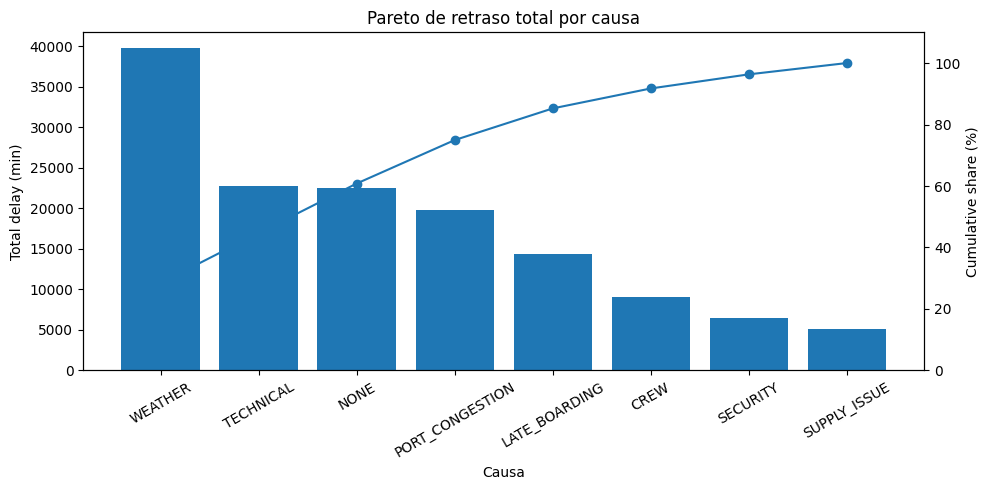

In [19]:
import matplotlib.pyplot as plt

# Asegúrate de tener pareto calculado
pareto_plot = pareto.copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Barras: retraso total
ax1.bar(pareto_plot["disruption_reason"], pareto_plot["total_delay_min"])
ax1.set_title("Pareto de retraso total por causa")
ax1.set_ylabel("Total delay (min)")
ax1.set_xlabel("Causa")
ax1.tick_params(axis="x", rotation=30)

# Línea: acumulado %
ax2 = ax1.twinx()
ax2.plot(pareto_plot["disruption_reason"], pareto_plot["cum_share_%"], marker="o")
ax2.set_ylabel("Cumulative share (%)")
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig("reports/figures/pareto_delay.png", dpi=200, bbox_inches="tight")
plt.show()

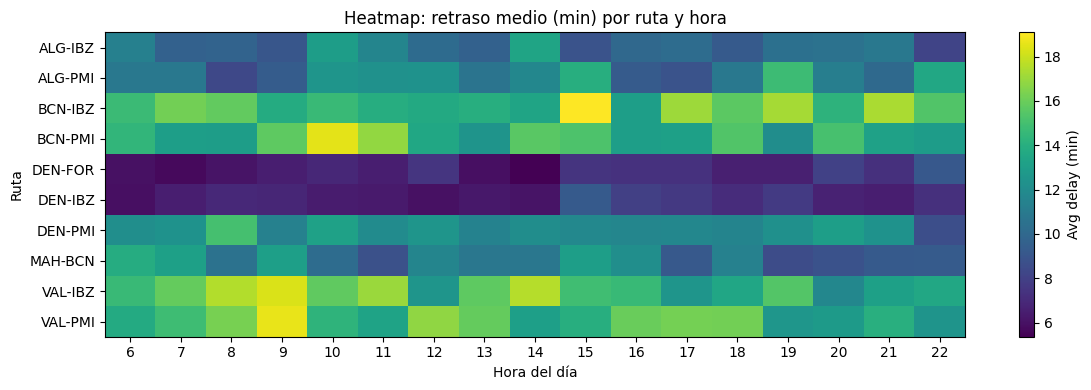

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz route x hour con delay medio
pivot = (non_cancel
         .groupby(["route_id", "hour"])["delay_min"]
         .mean()
         .reset_index()
         .pivot(index="route_id", columns="hour", values="delay_min")
)

# Orden de horas (0-23) por si faltan columnas
pivot = pivot.reindex(columns=sorted(pivot.columns))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect="auto")

ax.set_title("Heatmap: retraso medio (min) por ruta y hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Ruta")

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

plt.colorbar(im, ax=ax, label="Avg delay (min)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-37851/771214703.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


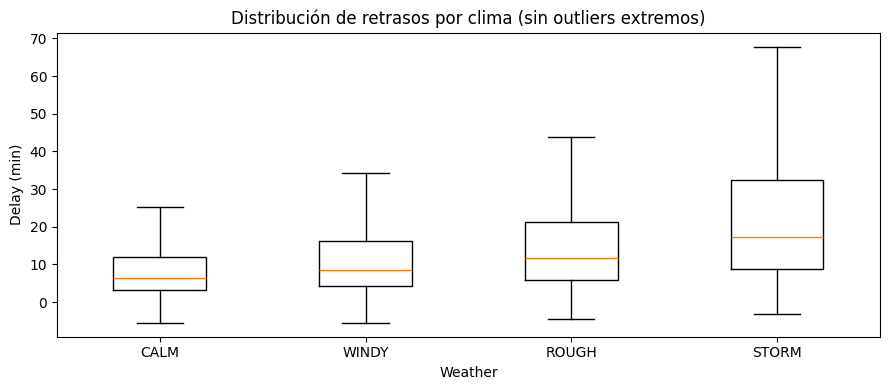

In [21]:
import matplotlib.pyplot as plt

order = ["CALM", "WINDY", "ROUGH", "STORM"]
data = [non_cancel.loc[non_cancel["weather"] == w, "delay_min"].dropna().values for w in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=order, showfliers=False)

ax.set_title("Distribución de retrasos por clima (sin outliers extremos)")
ax.set_xlabel("Weather")
ax.set_ylabel("Delay (min)")

plt.tight_layout()
plt.show()

In [22]:
import os
os.makedirs("reports/figures", exist_ok=True)

# Tabla “Top focos operativos” (ruta + hora + causa)

In [23]:
focus = (non_cancel
         .groupby(["route_id", "hour", "disruption_reason"])
         .agg(
             services=("operation_id", "count"),
             total_delay=("delay_min", "sum"),
             avg_delay=("delay_min", "mean"),
             p95_delay=("delay_min", lambda x: x.quantile(0.95)),
             on_time_15=("delay_min", lambda x: (x <= 15).mean())
         )
         .reset_index()
)

focus["on_time_15_%"] = (focus["on_time_15"]*100).round(2)
focus["avg_delay"] = focus["avg_delay"].round(2)
focus["p95_delay"] = focus["p95_delay"].round(2)
focus["total_delay"] = focus["total_delay"].round(0)

# Ranking: mucho retraso agregado y suficiente volumen
focus_rank = (focus[focus["services"] >= 30]
              .sort_values(["total_delay", "avg_delay"], ascending=False)
              .head(15))

focus_rank

,route_id,hour,disruption_reason,services,total_delay,avg_delay,p95_delay,on_time_15,on_time_15_%
345,BCN-IBZ,16,NONE,31,248.0,8.01,18.00,0.903226,90.32
429,BCN-PMI,10,NONE,32,245.0,7.66,19.01,0.875000,87.50
1152,VAL-IBZ,18,NONE,31,237.0,7.64,17.90,0.838710,83.87
965,MAH-BCN,11,NONE,37,225.0,6.07,17.62,0.891892,89.19
219,ALG-PMI,17,NONE,33,219.0,6.63,15.10,0.909091,90.91
1228,VAL-PMI,11,NONE,31,216.0,6.96,17.70,0.903226,90.32
469,BCN-PMI,15,NONE,33,214.0,6.50,17.80,0.878788,87.88
1291,VAL-PMI,19,NONE,31,201.0,6.49,14.75,0.935484,93.55
830,DEN-PMI,11,NONE,31,198.0,6.40,19.15,0.903226,90.32
281,BCN-IBZ,8,NONE,30,189.0,6.31,15.42,0.933333,93.33


# Simulación simple: “si reduzco X% WEATHER y TECHNICAL, ¿cuánto mejora?”

In [24]:
total_delay_all = non_cancel["delay_min"].sum()

delay_by_reason = non_cancel.groupby("disruption_reason")["delay_min"].sum()

# escenarios (ajustables)
scenarios = [
    {"name": "Reduce WEATHER 10%", "WEATHER": 0.10},
    {"name": "Reduce TECHNICAL 10%", "TECHNICAL": 0.10},
    {"name": "Reduce WEATHER 10% + TECHNICAL 10%", "WEATHER": 0.10, "TECHNICAL": 0.10},
    {"name": "Reduce PORT_CONGESTION 10%", "PORT_CONGESTION": 0.10},
]

rows = []
for s in scenarios:
    saved = 0.0
    for reason, pct in s.items():
        if reason == "name":
            continue
        saved += delay_by_reason.get(reason, 0) * pct
    rows.append({
        "scenario": s["name"],
        "delay_saved_min": round(saved, 1),
        "delay_saved_%": round(saved / total_delay_all * 100, 2)
    })

pd.DataFrame(rows).sort_values("delay_saved_%", ascending=False)

,scenario,delay_saved_min,delay_saved_%
2,Reduce WEATHER 10% + TECHNICAL 10%,6249.5,4.47
0,Reduce WEATHER 10%,3975.5,2.84
1,Reduce TECHNICAL 10%,2274.0,1.63
3,Reduce PORT_CONGESTION 10%,1976.0,1.41


# Reglas de alerta “Control Tower” (lista de rutas en rojo)

In [25]:
route_ops = (non_cancel
             .groupby("route_id")
             .agg(
                 services=("operation_id","count"),
                 avg_delay=("delay_min","mean"),
                 p95_delay=("delay_min", lambda x: x.quantile(0.95)),
                 on_time_15=("delay_min", lambda x: (x <= 15).mean()),
                 avg_margin=("margin","mean")
             )
             .reset_index())

route_ops["on_time_15_%"] = (route_ops["on_time_15"]*100).round(2)
route_ops["avg_delay"] = route_ops["avg_delay"].round(2)
route_ops["p95_delay"] = route_ops["p95_delay"].round(2)
route_ops["avg_margin"] = route_ops["avg_margin"].round(2)

# Semáforo (ajustable)
def flag(row):
    if row["on_time_15_%"] < 60 or row["p95_delay"] > 60:
        return "RED"
    if row["on_time_15_%"] < 70 or row["p95_delay"] > 45:
        return "AMBER"
    return "GREEN"

route_ops["status"] = route_ops.apply(flag, axis=1)

route_ops.sort_values(["status","avg_delay"], ascending=[True, False])

,route_id,services,avg_delay,p95_delay,on_time_15,avg_margin,on_time_15_%,status
2,BCN-IBZ,1192,15.18,44.30,0.655201,25818.48,65.52,AMBER
8,VAL-IBZ,1176,15.02,44.75,0.649660,25981.49,64.97,AMBER
9,VAL-PMI,1213,14.84,42.88,0.642209,24006.10,64.22,AMBER
3,BCN-PMI,1232,14.41,40.14,0.662338,23682.85,66.23,AMBER
6,DEN-PMI,1175,12.15,34.56,0.717447,28622.43,71.74,GREEN
1,ALG-PMI,1156,11.24,35.62,0.758651,23871.05,75.87,GREEN
7,MAH-BCN,1147,10.87,31.00,0.758500,28956.44,75.85,GREEN
0,ALG-IBZ,1209,10.44,30.50,0.777502,24784.65,77.75,GREEN
5,DEN-IBZ,1157,6.93,21.60,0.885912,33541.22,88.59,GREEN
4,DEN-FOR,1157,6.81,19.60,0.898012,32680.70,89.80,GREEN


# recalcular focos excluyendo “NONE”

In [26]:
focus_rank_actions = (focus
    .query("disruption_reason != 'NONE' and services >= 20")
    .sort_values(["total_delay", "avg_delay"], ascending=False)
    .head(15)
)

focus_rank_actions

,route_id,hour,disruption_reason,services,total_delay,avg_delay,p95_delay,on_time_15,on_time_15_%
1249,VAL-PMI,13,WEATHER,22,564.0,25.61,51.61,0.318182,31.82
1233,VAL-PMI,11,WEATHER,22,481.0,21.88,42.96,0.500000,50.00
1085,VAL-IBZ,9,WEATHER,21,476.0,22.68,57.20,0.476190,47.62
168,ALG-PMI,10,WEATHER,23,455.0,19.79,50.39,0.521739,52.17
342,BCN-IBZ,15,WEATHER,20,433.0,21.66,47.74,0.400000,40.00
38,ALG-IBZ,10,WEATHER,20,399.0,19.94,41.92,0.450000,45.00
891,DEN-PMI,18,WEATHER,22,345.0,15.66,31.71,0.454545,45.45
108,ALG-IBZ,19,WEATHER,21,344.0,16.39,42.40,0.619048,61.90
1109,VAL-IBZ,12,WEATHER,21,316.0,15.07,32.40,0.666667,66.67
46,ALG-IBZ,11,WEATHER,21,313.0,14.90,42.40,0.714286,71.43


In [27]:
#carpetas de salida
import os
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

In [28]:
#Exportacion de tablas
# Tablas clave
kpi_exec.to_csv("reports/kpi_executive_summary.csv", index=False)
route_kpis.to_csv("reports/route_kpis.csv", index=False)
pareto.to_csv("reports/pareto_delay_by_reason.csv", index=False)
pareto_margin.to_csv("reports/pareto_margin_by_reason.csv", index=False)
hotspots.to_csv("reports/hotspots_route_hour.csv", index=False)
focus_rank.to_csv("reports/focus_rank_all.csv", index=False)
focus_rank_actions.to_csv("reports/focus_rank_actions.csv", index=False)
route_ops.to_csv("reports/route_ops_traffic_light.csv", index=False)

print("OK: CSVs exportados a /reports")

OK: CSVs exportados a /reports


In [29]:
#guarda de dataset
df.to_csv("data/processed/ferry_operations_processed.csv", index=False)
print("OK: dataset procesado guardado en data/processed/ferry_operations_processed.csv")

OK: dataset procesado guardado en data/processed/ferry_operations_processed.csv


In [30]:
#guarda de figuras
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Pareto ---
pareto_plot = pareto.copy()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(pareto_plot["disruption_reason"], pareto_plot["total_delay_min"])
ax1.set_title("Pareto de retraso total por causa")
ax1.set_ylabel("Total delay (min)")
ax1.set_xlabel("Causa")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(pareto_plot["disruption_reason"], pareto_plot["cum_share_%"], marker="o")
ax2.set_ylabel("Cumulative share (%)")
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig("reports/figures/pareto_delay.png", dpi=200, bbox_inches="tight")
plt.close()

# --- 2) Heatmap route x hour ---
pivot = (non_cancel
         .groupby(["route_id", "hour"])["delay_min"]
         .mean()
         .reset_index()
         .pivot(index="route_id", columns="hour", values="delay_min")
)
pivot = pivot.reindex(columns=sorted(pivot.columns))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Heatmap: retraso medio (min) por ruta y hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Ruta")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

plt.colorbar(im, ax=ax, label="Avg delay (min)")
plt.tight_layout()
plt.savefig("reports/figures/heatmap_route_hour_delay.png", dpi=200, bbox_inches="tight")
plt.close()

# --- 3) Boxplot delay por weather ---
order = ["CALM", "WINDY", "ROUGH", "STORM"]
data = [non_cancel.loc[non_cancel["weather"] == w, "delay_min"].dropna().values for w in order]

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_title("Distribución de retrasos por clima (sin outliers extremos)")
ax.set_xlabel("Weather")
ax.set_ylabel("Delay (min)")

plt.tight_layout()
plt.savefig("reports/figures/boxplot_delay_by_weather.png", dpi=200, bbox_inches="tight")
plt.close()

print("OK: figuras guardadas en reports/figures/")

OK: figuras guardadas en reports/figures/


/tmp/ipython-input-37851/229734023.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


In [31]:
#reportes automaticos
# Datos para el summary
k = kpi_exec.iloc[0].to_dict()

top_delay_routes = (route_kpis.sort_values("avg_delay_min", ascending=False)
                    [["route_id","avg_delay_min","p95_delay_min","on_time_rate_%","avg_margin"]]
                    .head(5))

amber_routes = (route_ops[route_ops["status"]=="AMBER"]
                .sort_values("avg_delay", ascending=False)
                [["route_id","on_time_15_%","avg_delay","p95_delay","avg_margin"]])

top_causes = pareto[["disruption_reason","share_%","cum_share_%","avg_delay_min","p95_delay_min"]].head(5)

# tabla OTR thresholds
otr_text = (
    f"- OTR ≤ 5 min: {comp[0]['on_time_rate_%']}%\n"
    f"- OTR ≤ 15 min: {comp[1]['on_time_rate_%']}%\n"
)

# escenarios
scenario_lines = []
for _, r in pd.DataFrame(rows).sort_values("delay_saved_%", ascending=False).iterrows():
    scenario_lines.append(f"- {r['scenario']}: ahorro ~{r['delay_saved_%']}% ({r['delay_saved_min']} min)")

summary = []
summary.append("# Executive Summary — Control Operativo y Eficiencia (Ferries)\n")
summary.append("## KPIs globales\n")
summary.append(f"- Servicios totales: **{int(k['services_total'])}**\n")
summary.append(f"- Servicios completados: **{int(k['services_completed'])}**\n")
summary.append(f"- Cancel Rate: **{k['cancel_rate_%']}%**\n")
summary.append(f"- Delay medio: **{k['avg_delay_min']} min** | P95: **{k['p95_delay_min']} min**\n")
summary.append(f"- Ocupación media: **{k['avg_occupancy']}**\n")
summary.append(f"- Margen medio: **{k['avg_margin']}** | Margen total: **{k['total_margin']}**\n\n")

summary.append("## Puntualidad (sensibilidad del umbral)\n")
summary.append(otr_text + "\n")

summary.append("## Top rutas por retraso medio\n")
summary.append(top_delay_routes.to_markdown(index=False) + "\n\n")

summary.append("## Pareto de causas (retraso total)\n")
summary.append(top_causes.to_markdown(index=False) + "\n\n")

summary.append("## Semáforo de rutas (OTR≤15 + P95)\n")
if len(amber_routes) == 0:
    summary.append("- No hay rutas AMBER con la regla actual.\n\n")
else:
    summary.append(amber_routes.to_markdown(index=False) + "\n\n")

summary.append("## Impacto estimado (escenarios)\n")
summary.append("\n".join(scenario_lines) + "\n\n")

summary.append("## Figuras\n")
summary.append("- `reports/figures/pareto_delay.png`\n")
summary.append("- `reports/figures/heatmap_route_hour_delay.png`\n")
summary.append("- `reports/figures/boxplot_delay_by_weather.png`\n")

with open("reports/executive_summary.md", "w", encoding="utf-8") as f:
    f.write("".join(summary))

print("OK: creado reports/executive_summary.md")

OK: creado reports/executive_summary.md


In [32]:
#paso a zip
import shutil

zip_path = "ferry_project_reports.zip"
shutil.make_archive("ferry_project_reports", "zip", "reports")
print("ZIP creado:", zip_path)

from google.colab import files
files.download(zip_path)

ZIP creado: ferry_project_reports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import os, shutil

project_dir = "control-operativo-ferries"
os.makedirs(project_dir, exist_ok=True)

# carpetas base
for p in [
    f"{project_dir}/data/raw",
    f"{project_dir}/data/processed",
    f"{project_dir}/notebooks",
    f"{project_dir}/src",
    f"{project_dir}/reports/figures"
]:
    os.makedirs(p, exist_ok=True)

# mueve/copia outputs si existen
def safe_copy(src, dst):
    if os.path.exists(src):
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

safe_copy("reports", f"{project_dir}/reports")
safe_copy("data/processed", f"{project_dir}/data/processed")

# crea placeholders para carpetas vacías
open(f"{project_dir}/data/raw/.gitkeep", "w").close()
open(f"{project_dir}/src/.gitkeep", "w").close()

# .gitignore pro
gitignore = """data/raw/*
data/processed/*
!data/raw/.gitkeep
!data/processed/.gitkeep
__pycache__/
*.pyc
.ipynb_checkpoints/
"""
with open(f"{project_dir}/.gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore)

# README placeholder si no existe
if not os.path.exists(f"{project_dir}/README.md"):
    with open(f"{project_dir}/README.md", "w", encoding="utf-8") as f:
        f.write("# Proyecto 1 — Control Operativo y Eficiencia (Ferries)\n")

# zip
zip_name = "control-operativo-ferries"
shutil.make_archive(zip_name, "zip", project_dir)

from google.colab import files
files.download(f"{zip_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>